# Chapter 3.3.1 - A simple self-attention mechanism without trainable weights

In [1]:
import torch

##### lets take a sentence as input

##### Your journey starts with one step

In [2]:
inputs=torch.tensor([
[0.43, 0.15, 0.89], #embedding vector of token "your" 
[0.55, 0.87, 0.66], #embedding vector of token "journey" 
[0.57, 0.85, 0.64], #embedding vector of token "starts" 
[0.22, 0.58, 0.33], #embedding vector of token "with" 
[0.77, 0.25, 0.10], #embedding vector of token "one " 
[0.05, 0.80, 0.55]] #embedding vector of token "step" 
)

##### each row above is the embedding of one token. so all together for 6 tokens we have 6 embedding vectors of 3 dim

In [3]:
print(inputs[1]) 

tensor([0.5500, 0.8700, 0.6600])


In [4]:
inputs.shape

torch.Size([6, 3])

##### what we need to do now is we need to calculate so called attention score, and how we do it is by taking one token's embedding vector at a time as input and doing the dot product with itself and all the other token's embedding vectors.

##### to understand how this works, lets take the first token embedding vector as input and calculate its  dot product with all

In [5]:
# select the first token's embedding as the query vector.
query = inputs[0]

# create an empty tensor to store one attention score
# for each input token.
# inputs.shape[0] = 6, so attn_scores will have 6 values.
attn_scores = torch.empty(inputs.shape[0])

# loop through all input token embeddings.
for i in range(inputs.shape[0]):

    # compute the dot product between the query embedding
    # and the current token's embedding (inputs[i]).
    # each dot product returns a single value. Since there
    # are 6 input tokens, we compute 6 dot products,
    # resulting in 6 attention scores.
    # each score represents the similarity between the
    # query embedding and one input embedding.
    attn_scores[i] = torch.dot(query, inputs[i])

# print the attention scores
print(attn_scores)

tensor([0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310])


In [6]:
##### sample example of how dot product works
query=inputs[0]
for i in range(inputs.shape[0]):
    print("query=" ,query)
    print("input=" ,inputs[i])
    multiply=query* inputs[i]
    print("element wise multiplication: \n ",multiply)
    final_value=torch.sum((multiply))
    print("output_value after addition of all = ",final_value)
    print("*****************************************************")

query= tensor([0.4300, 0.1500, 0.8900])
input= tensor([0.4300, 0.1500, 0.8900])
element wise multiplication: 
  tensor([0.1849, 0.0225, 0.7921])
output_value after addition of all =  tensor(0.9995)
*****************************************************
query= tensor([0.4300, 0.1500, 0.8900])
input= tensor([0.5500, 0.8700, 0.6600])
element wise multiplication: 
  tensor([0.2365, 0.1305, 0.5874])
output_value after addition of all =  tensor(0.9544)
*****************************************************
query= tensor([0.4300, 0.1500, 0.8900])
input= tensor([0.5700, 0.8500, 0.6400])
element wise multiplication: 
  tensor([0.2451, 0.1275, 0.5696])
output_value after addition of all =  tensor(0.9422)
*****************************************************
query= tensor([0.4300, 0.1500, 0.8900])
input= tensor([0.2200, 0.5800, 0.3300])
element wise multiplication: 
  tensor([0.0946, 0.0870, 0.2937])
output_value after addition of all =  tensor(0.4753)
**********************************************

##### we can see that the output value matces with tensor([0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310])

##### once we obtain the attention score, the next step is to normalize the attention scores to obtain attention weights  that sum up to 1. This normalization is a convention that is useful for interpretation and for maintaining training stability in an LLM

#### if we calculate the sum of attn score right now, its past 1.

In [7]:
sum_of_attn_scores=attn_scores.sum()
print(sum_of_attn_scores) 

tensor(4.4600)


##### to normalize it so that its sum becomes one, we take the attention score and divide it by its sum

In [8]:
attn_weights_temp= attn_scores/ sum_of_attn_scores
print(attn_weights_temp)

tensor([0.2241, 0.2140, 0.2113, 0.1066, 0.1026, 0.1415])


##### after normalizing if we calculate the sum of new normalized weights,it should be 1.

In [9]:
print(attn_weights_temp.sum())

tensor(1.)


##### in practice, it's more common and advisable to use the softmax function for normalization. this approach is better at managing extreme values and offers more favorable gradient properties during training. below is a basic implementation of the softmax function for normalizing the attention scores:

In [10]:
print(attn_scores.sum())

tensor(4.4600)


In [11]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights= softmax_naive(attn_scores)
print(attn_weights)
print(attn_weights.sum())

tensor([0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452])
tensor(1.0000)


##### as the output shows, the softmax function also meets the objective and normalizes the attention weights such that they sum to 1:

In addition, the softmax function ensures that the attention weights are always positive.
This makes the output interpretable as probabilities or relative importance, where higher
weights indicate greater importance.
Note that this naive softmax implementation (softmax_naive) may encounter numerical
instability problems, such as overflow and underflow, when dealing with large or small input
values. Therefore, in practice, it's advisable to use the PyTorch implementation of softmax,
which has been extensively optimized for performance:


In [12]:
print(attn_scores)

tensor([0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310])


In [13]:
attn_weights= torch.softmax(attn_scores,dim=0)
print(attn_weights)
print(attn_weights.sum())

tensor([0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452])
tensor(1.0000)


##### we can see that it yields the same results as our previous softmax_naive function, but this implemenationis highly optimizede for performance

##### now that computed the normalized attention weights, we are ready for the final step ie calculating the context vector z by multiplying the embedded input tokens with the corresponding attention weights and then summing the resulting vectors.

In [14]:
query=inputs[0]
print(query.shape)

torch.Size([3])


In [15]:
print(inputs[0])

tensor([0.4300, 0.1500, 0.8900])


In [16]:
query=inputs[0]
#create a zeero vector with same shape as query embedding to store the context values.
contxt_vec= torch.zeros(query.shape)
#compute context vectors and add them to the contxt_vec.
for i in range(inputs.shape[0]):
    contxt_vec= contxt_vec+ inputs[i]* attn_weights[i] 
print(contxt_vec)

tensor([0.4421, 0.5931, 0.5790])


# Chapter 3.3.2 Computing attention weights for all input tokens

##### we will now generalize this procedure for computing context vectors to calculate all context vectors simultaneously

##### we previously completed  computing attention weights and context veector for input[0] ie first token embeddings.

##### Now, we are extending this computation to calculate attention weights and context vectors for all inputs

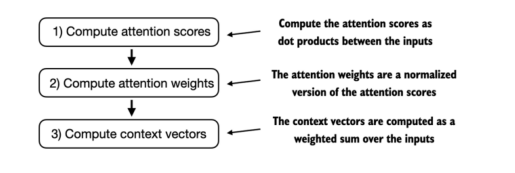

In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("atn_steps.png")

plt.imshow(img)
plt.axis("off")
plt.show()

##### we follow the same three steps as before,except that we make a few modifications in the code to compute all context vectors instead of only the first context vector

In [18]:
print(inputs.shape)

torch.Size([6, 3])


##### attention score between two tokens is computed  using the dot product of every token with every other token.so, the attention score would look something like this

##### each token will do dot product with every other token, and we would get a 6*6 matrix where,

In [24]:
attn_scores =torch.empty(6,6)
for i in range(len(inputs)):
    for j in range(len(inputs)):
        attn_scores[i,j]=torch.dot(inputs[i],inputs[j])
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


##### Each element in the preceding tensor represents an attention score between each pair of inputs. right now these values are not normalized.

In [27]:
print(attn_scores.sum())

tensor(29.0070)


##### we need to normalize the attention score to get the attention weights,but before that:

##### When computing the preceding attention score tensor, we used for-loops in Python.However, for-loops are generally slow, and we can achieve the same results using matrix multiplication:


In [29]:
attn_scores=inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


##### as we  can see,we used matrix multiplication which are faster and best to use 

##### now we normalize these values to get the attention weights,in order to do that we use sotfmax function in torch

In [30]:
attn_weights=torch.softmax(attn_scores,dim=1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


##### these values are now normalized

##### each row represents the attention weights for each token,we can  check to see if the sum of those weights for single row is 1 or not

In [34]:
print(attn_weights[0].sum()) 

tensor(1.0000)


In [35]:
print(attn_weights[2].sum()) 

tensor(1.0000)


##### the final step is to compute the context vector for every input token. earlier, we calculated the context vector for only a single token to understand how self-attention works. we now repeat the same process for each of the 6 input tokens. as a result, we obtain 6 context vectors,one corresponding to each input token.

##### to do that , we just need to perform matrix multiplication of input with the attention weights

In [36]:
all_context_vecs= attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


##### in the resulting output tensor, each row contains a 3-dimensional context vector:

##### if we look  up the previous context vector we generated for first input ie,tensor([0.4421, 0.5931, 0.5790]) we can see that its same. so its working

##### this completes the walkthrough of simple self-attention mechanism,next we will add trainable weights, enabling the LLM to learn from data and improve its performance on specific tasks.